In [1]:
from gensim.models import Word2Vec
from pathlib import Path

BASE_DIR = Path().resolve().parent  # project root
model_path = BASE_DIR / "models" / "action2vec.model"

model = Word2Vec.load(str(model_path))
print("Vocabulary:", list(model.wv.key_to_index.keys()))

# SHOT_ON and SHOT_OFF should be near each other
# PRESS and INT should be near each other (both defensive)
similar = model.wv.most_similar('SHOT_ON', topn=5)
print("\nMost similar to SHOT_ON:", similar)

print("\nSimilar to PRESS:")
print(model.wv.most_similar('PRESS', topn=4))

Vocabulary: ['CARRY', 'CARRY_WIDE', 'PRESS', 'PASS_PROG', 'CARRY_PROG', 'CARRY_WIDE_PROG', 'CLEARANCE', 'PASS_BACK', 'FOUL_W', 'PASS_CROSS', 'DRIBBLE_W', 'DRIBBLE_L', 'SHOT_OFF_BOX', 'INT', 'SHOT_ON_BOX', 'SHOT_OFF', 'SHOT_ON']

Most similar to SHOT_ON: [('SHOT_OFF_BOX', 0.9914737939834595), ('SHOT_OFF', 0.9691232442855835), ('SHOT_ON_BOX', 0.9614322185516357), ('CLEARANCE', 0.48503464460372925), ('INT', 0.44995030760765076)]

Similar to PRESS:
[('DRIBBLE_L', 0.40988507866859436), ('SHOT_ON', 0.40946435928344727), ('DRIBBLE_W', 0.4010564386844635), ('PASS_PROG', 0.3830377459526062)]


In [2]:
import numpy as np, json

matrix     = np.load('../models/player_matrix.npy')
player_ids = json.load(open('../models/player_ids.json'))

print(f"Player matrix shape: {matrix.shape}")
# Should be (N_players, 64) — e.g. (600, 64)

print(f"Number of players: {len(player_ids)}")
print(f"Example player IDs: {player_ids[:5]}")

Player matrix shape: (1059, 128)
Number of players: 1059
Example player IDs: [5213.0, 10609.0, 5216.0, 5503.0, 11179.0]


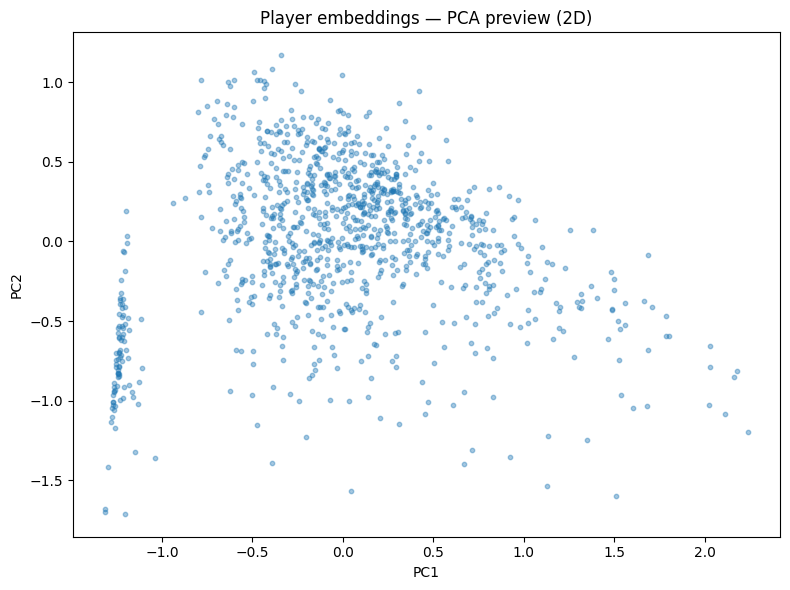

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA is much faster than UMAP for a quick preview
pca   = PCA(n_components=2, random_state=42)
pts   = pca.fit_transform(matrix)

plt.figure(figsize=(8,6))
plt.scatter(pts[:,0], pts[:,1], alpha=0.4, s=10)
plt.title('Player embeddings — PCA preview (2D)')
plt.xlabel('PC1'), plt.ylabel('PC2')
plt.tight_layout()
plt.show()
# You should see some loose clusters forming — not random noise

In [4]:
import numpy as np, json
from sklearn.decomposition import PCA

matrix     = np.load('../models/player_matrix.npy')
player_ids = json.load(open('../models/player_ids.json'))

pca = PCA(n_components=2, random_state=42)
pts = pca.fit_transform(matrix)

# Find the diagonal line — those are points where PC1 < -0.2
diagonal_mask    = pts[:, 0] < -0.2
diagonal_players = [player_ids[i] for i, m in enumerate(diagonal_mask) if m]
print("Players in the diagonal cluster:")
print(diagonal_players[:10])

Players in the diagonal cluster:
[5213.0, 10609.0, 5216.0, 5503.0, 11179.0, 5211.0, 20016.0, 5201.0, 5506.0, 5721.0]


In [5]:
import warnings
from statsbombpy.api_client import NoAuthWarning

warnings.filterwarnings("ignore", category=NoAuthWarning)

In [6]:
from statsbombpy import sb

matches = sb.matches(competition_id=11, season_id=26)
lineups = sb.lineups(match_id=matches.iloc[0]['match_id'])

# lineups is a dict of {team_name: DataFrame}
for team, df in lineups.items():
    print(df[['player_id', 'player_name', 'positions']].head(12))

    player_id                          player_name  \
0        3058            Javier Hernández Balcázar   
1        3990                  Jesé Rodríguez Ruiz   
2        4926       Francisco Román Alarcón Suárez   
3        5201                  Sergio Ramos García   
4        5207  Cristiano Ronaldo dos Santos Aveiro   
5        5463                          Luka Modrić   
6        5485                       Raphaël Varane   
7        5552       Marcelo Vieira da Silva Júnior   
8        5574                           Toni Kroos   
9        5597                  Keylor Navas Gamboa   
10       5721                Daniel Carvajal Ramos   
11       6399                    Gareth Frank Bale   

                                            positions  
0                                                  []  
1   [{'position_id': 15, 'position': 'Left Center ...  
2   [{'position_id': 15, 'position': 'Left Center ...  
3   [{'position_id': 5, 'position': 'Left Center B...  
4   [{'position_i